# LOLA exercices

## Install and load the required libraries

The following installation process depends on which environment you are using to execute the code. Run just one of the following cells to install the necessary libraries to run the code.

In [1]:
# Run this cell if you are in a Windows PC of the computer room
# Create a virtual environment and activate it

# !python -m venv .venv
# !.venv\Scripts\activate.bat

In [3]:
# Lab PCs
# !pip install --user numpy==1.26.4 matplotlib==3.8.4 rasterio==1.4.3 pvl==1.3.2

# Any version
%pip install numpy matplotlib rasterio pvl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlretrieve
import rasterio # Read IMG files files
import pvl # Read LBL files


## Download data

In [3]:
urlretrieve("https://imbrium.mit.edu/DATA/LOLA_GDR/CYLINDRICAL/IMG/LDEM_16.LBL", "LDEM_16.LBL")
urlretrieve("https://imbrium.mit.edu/DATA/LOLA_GDR/CYLINDRICAL/IMG/LDEM_16.IMG", "LDEM_16.IMG")


('LDEM_16.IMG', <http.client.HTTPMessage at 0x7b4fb1c3c770>)

## Example code to generate a height map

In [4]:
file_name = "LDEM_16.LBL"

src = rasterio.open(file_name)

In [5]:
print(src.meta)

{'driver': 'PDS', 'dtype': 'int16', 'nodata': -32768.0, 'width': 5760, 'height': 2880, 'count': 1, 'crs': CRS.from_wkt('PROJCS["SIMPLE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",180],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1895.21, 0.0, -5458204.8,
       0.0, -1895.21, 2729102.4)}


In [6]:
dem = src.read(1)
dem.shape

(2880, 5760)

In [7]:
# -- Load .lbl file to obtain parameters
lbl_file = pvl.load(file_name)
scale = lbl_file["UNCOMPRESSED_FILE"]["IMAGE"]["SCALING_FACTOR"]
offset = lbl_file["UNCOMPRESSED_FILE"]["IMAGE"]["OFFSET"]

scale, offset

(0.5, 1737400.0)

In [8]:
# -- Apply scale and offset
# Elevation in meters
dem_scale = (dem * scale)

# Distance from the center of mass
# dem_scale = (dem * scale) + offset

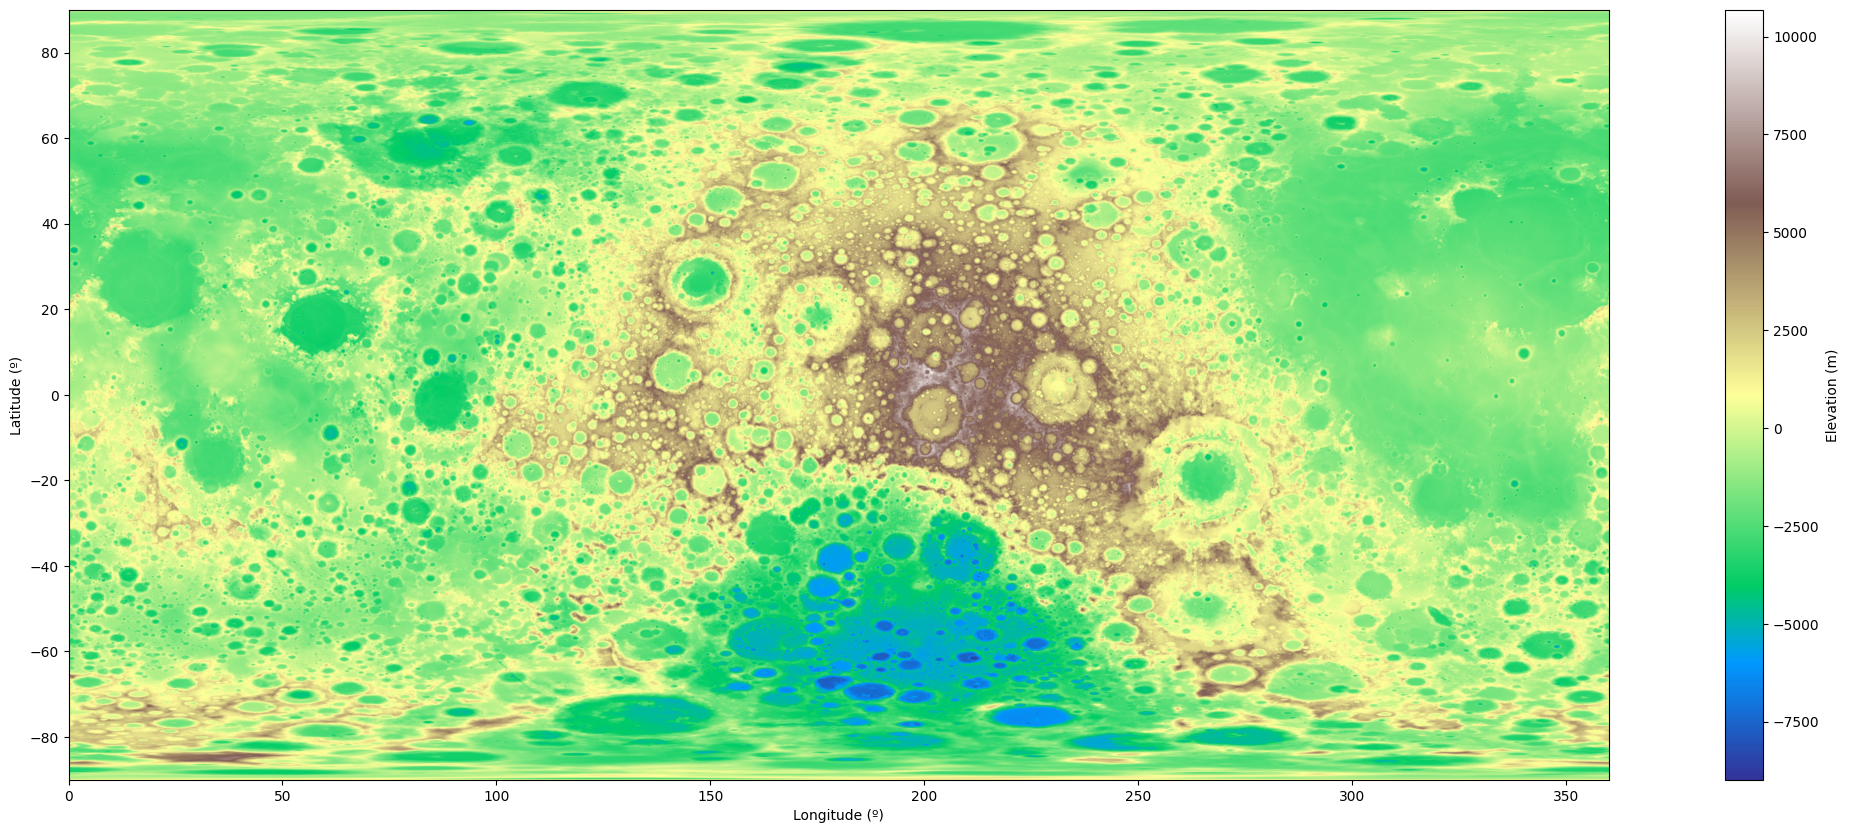

In [9]:
plt.figure(figsize=(30, 10))
plt.imshow(dem_scale, extent=[0, 360, -90, 90], cmap="terrain")
plt.xlabel("Longitude (º)")
plt.ylabel("Latitude (º)")
plt.colorbar(label="Elevation (m)")
plt.show()

# Exercice 1:


Generate a height map of the Moon as the one below but centered at the near side (0º longitude).

In [ ]:
# Write here the solution

# Exercice 2:


Give the coordinates of the highest and lowest points of the Moon’s surface on the near and far side

In [ ]:
# Write here the solution

# Exercice 3:


Create a histogram of heights for the near and the far side of the Moon.

In [ ]:
# Write here the solution

--------

# Exercice 4:


Create a map of the Permanently Shadowed Regions (PSRs) for both poles, given the average illumination, as the one on the right.

In [ ]:
# Write here the solution

# Exercice 5:


Where is the biggest PSR of the Moon? Give the coordinates of its approximate center.

In [10]:
# Write here the solution

# Exercice 6:


 Give an approximation of the proportion of the permanently shadowed projected area.

In [ ]:
# Write here the solution